# Explore here

**Carga y exploración de datos**

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('/workspaces/machine-learning-regresion-logistica-diabetes/data/raw/diabetes (2).csv')

print("Shape:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)
print("\nNulos (NaN reales):")
print(df.isnull().sum())
print("\nBalance de clases (Outcome):")
print(df['Outcome'].value_counts(normalize=True))

Shape: (768, 9)

Tipos de datos:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Nulos (NaN reales):
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Balance de clases (Outcome):
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


**Estadísticas descriptivas**

In [3]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Se observa que hay vaarias columnas con valor mínimo de 0, esto aunque fisilógicamente sería imposible tener 0, por lo que analizaremos la cantidad de ceros para determinar qué se hará con ellos.

In [4]:
# Cuantificar ceros sospechosos
cols_con_cero_invalido = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_con_cero_invalido:
    n_ceros = (df[col] == 0).sum()
    pct = n_ceros / len(df) * 100
    print(f"{col}: {n_ceros} ceros ({pct:.1f}%)")

Glucose: 5 ceros (0.7%)
BloodPressure: 35 ceros (4.6%)
SkinThickness: 227 ceros (29.6%)
Insulin: 374 ceros (48.7%)
BMI: 11 ceros (1.4%)


In [5]:
# Reemplazar ceros por NaN para tratarlos como missing reales
df_clean = df.copy()
df_clean[cols_con_cero_invalido] = df_clean[cols_con_cero_invalido].replace(0, np.nan)

print("Nulos tras reemplazo:")
print(df_clean.isnull().sum())

Nulos tras reemplazo:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [6]:
# Crear indicadores de "faltante" antes de imputar (para las columnas con mayor % de missing)
df_clean['Insulin_was_missing'] = df_clean['Insulin'].isnull().astype(int)
df_clean['SkinThickness_was_missing'] = df_clean['SkinThickness'].isnull().astype(int)

In [7]:
# Imputación con mediana simple (columnas con bajo % de missing)
cols_mediana_simple = ['Glucose', 'BloodPressure', 'BMI']

for col in cols_mediana_simple:
    mediana = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(mediana)

In [8]:
# Imputación con mediana agrupada por Outcome (columnas con alto % de missing)
cols_mediana_grupo = ['SkinThickness', 'Insulin']

for col in cols_mediana_grupo:
    df_clean[col] = df_clean.groupby('Outcome')[col].transform(
        lambda x: x.fillna(x.median())
    )

print("Nulos finales:")
print(df_clean.isnull().sum())

Nulos finales:
Pregnancies                  0
Glucose                      0
BloodPressure                0
SkinThickness                0
Insulin                      0
BMI                          0
DiabetesPedigreeFunction     0
Age                          0
Outcome                      0
Insulin_was_missing          0
SkinThickness_was_missing    0
dtype: int64


In [9]:
df_clean[cols_con_cero_invalido].describe()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI
count,768.000000,768.000000,768.000000,768.000000,768.000000
mean,121.656250,72.386719,29.089844,141.753906,32.455208
std,30.438286,12.096642,8.890820,89.100847,6.875177
min,44.000000,24.000000,7.000000,14.000000,18.200000
25%,99.750000,64.000000,25.000000,102.500000,27.500000
50%,117.000000,72.000000,28.000000,102.500000,32.300000
75%,140.250000,80.000000,32.000000,169.500000,36.600000
max,199.000000,122.000000,99.000000,846.000000,67.100000


Se crea un dataframe que rellene los valores faltantes con el valor de la mediana de las columnas, no se usa la media porque el valor sería bajo en comparación a los demás por el hecho de contar con varios o algunos valores nulos.

**Variables univariable y multivariable**

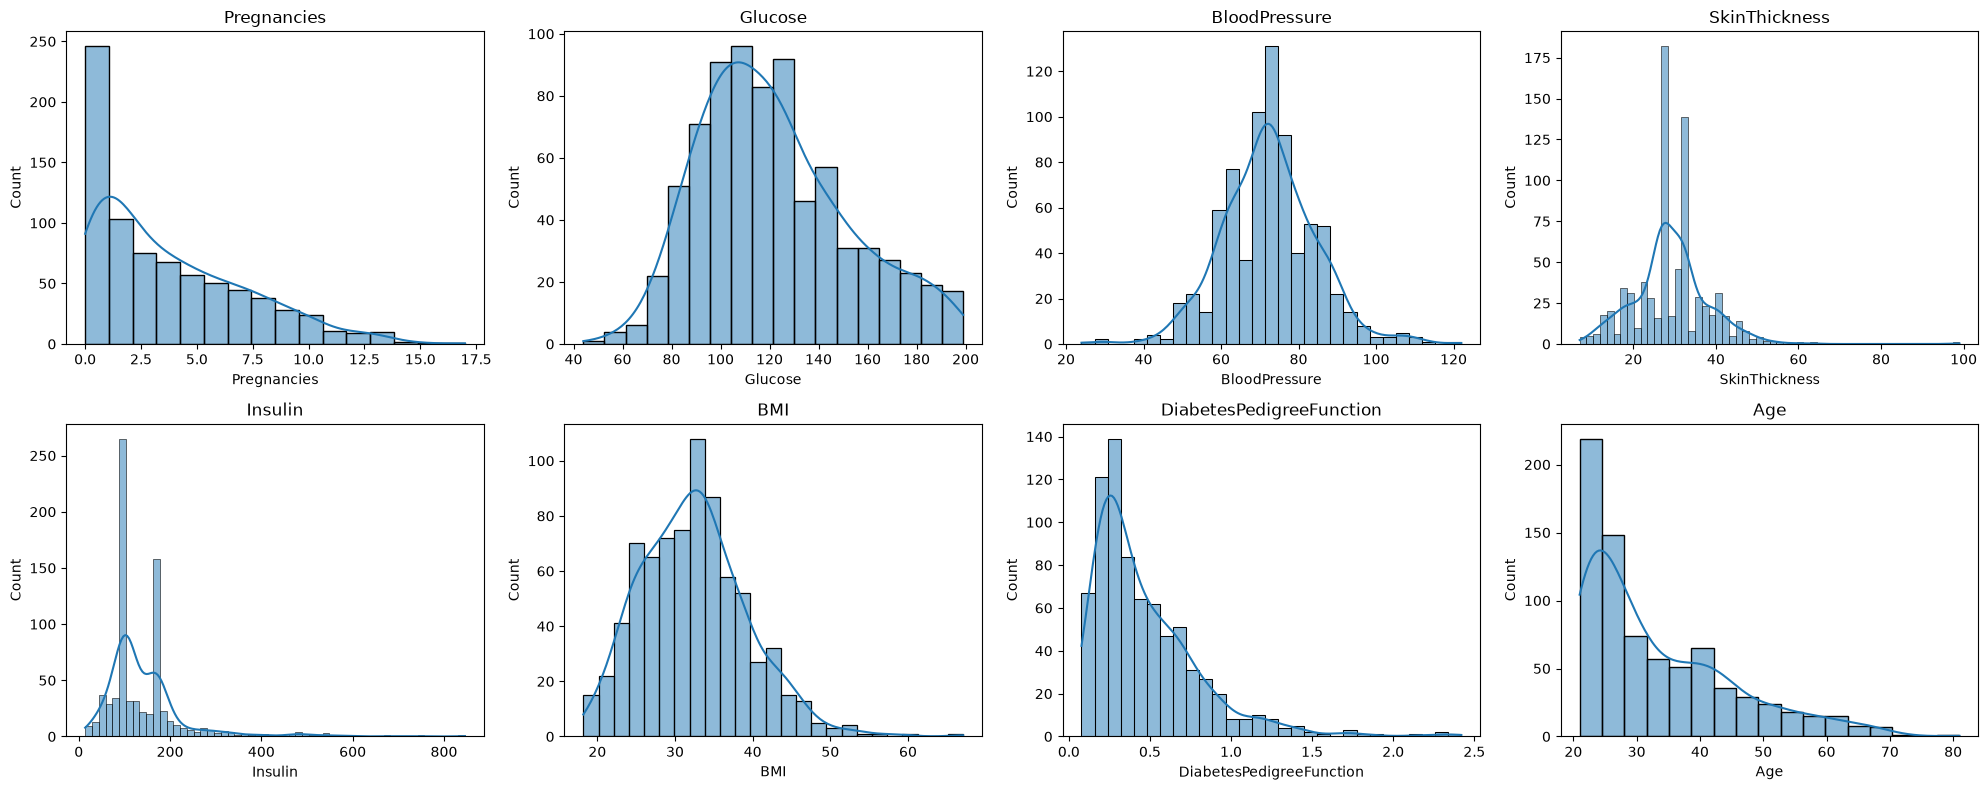

In [11]:
cols_numericas = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                   'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    sns.histplot(df_clean[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

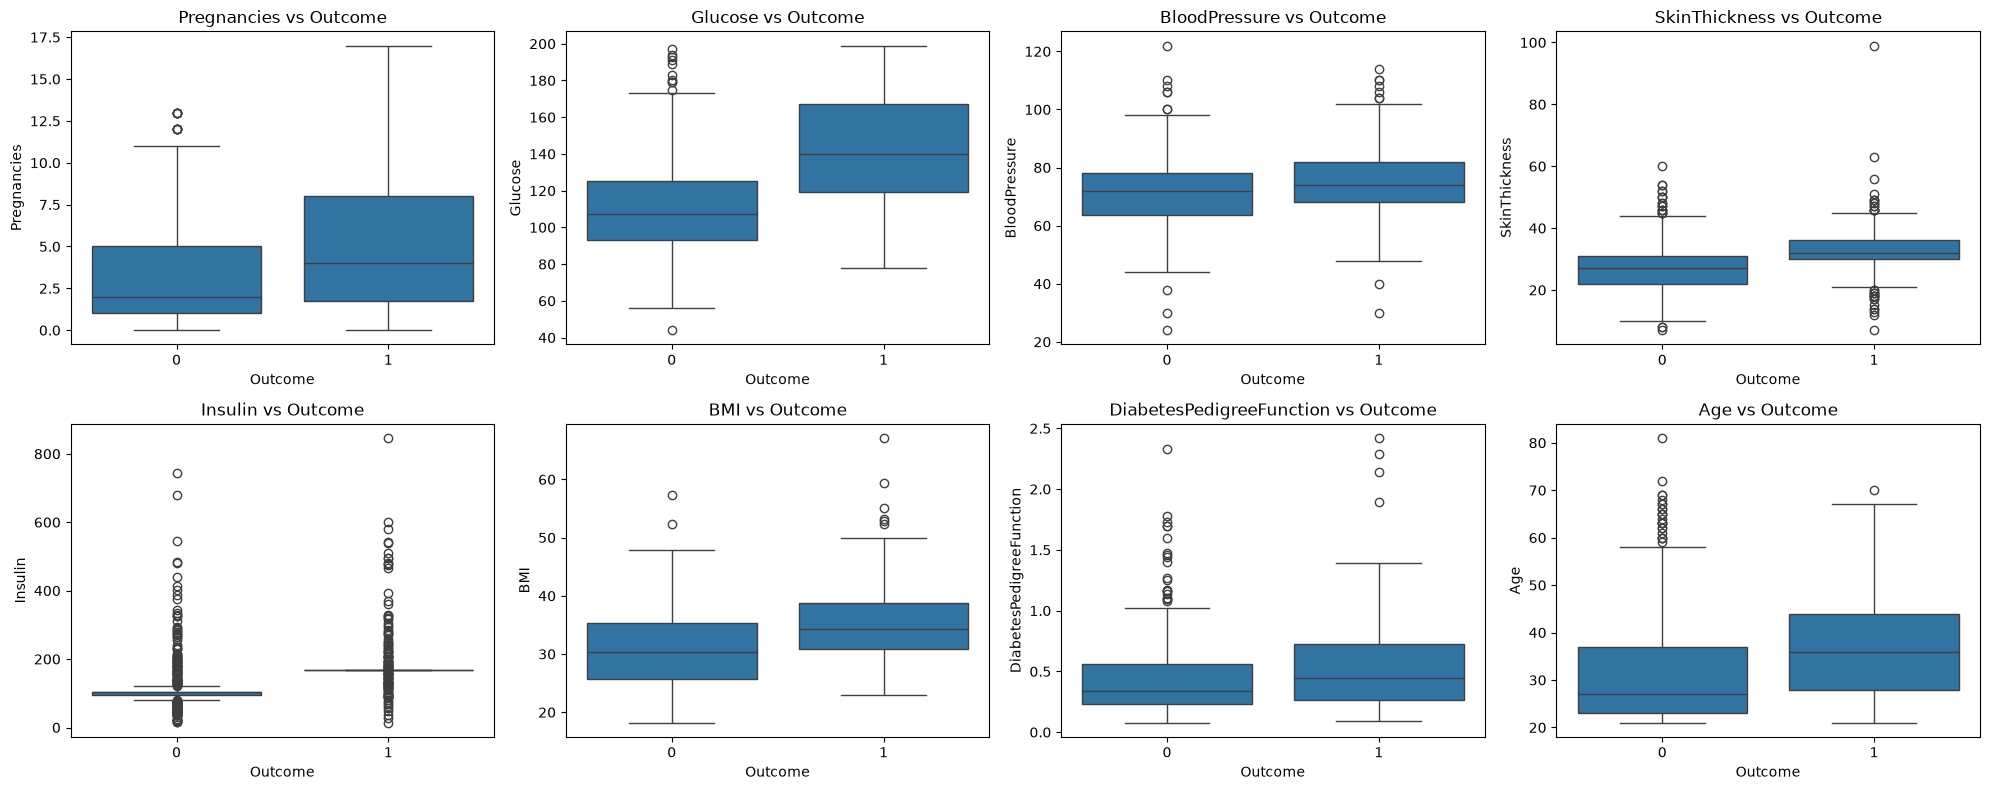

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    sns.boxplot(data=df_clean, x='Outcome', y=col, ax=axes[i])
    axes[i].set_title(f'{col} vs Outcome')

plt.tight_layout()
plt.show()

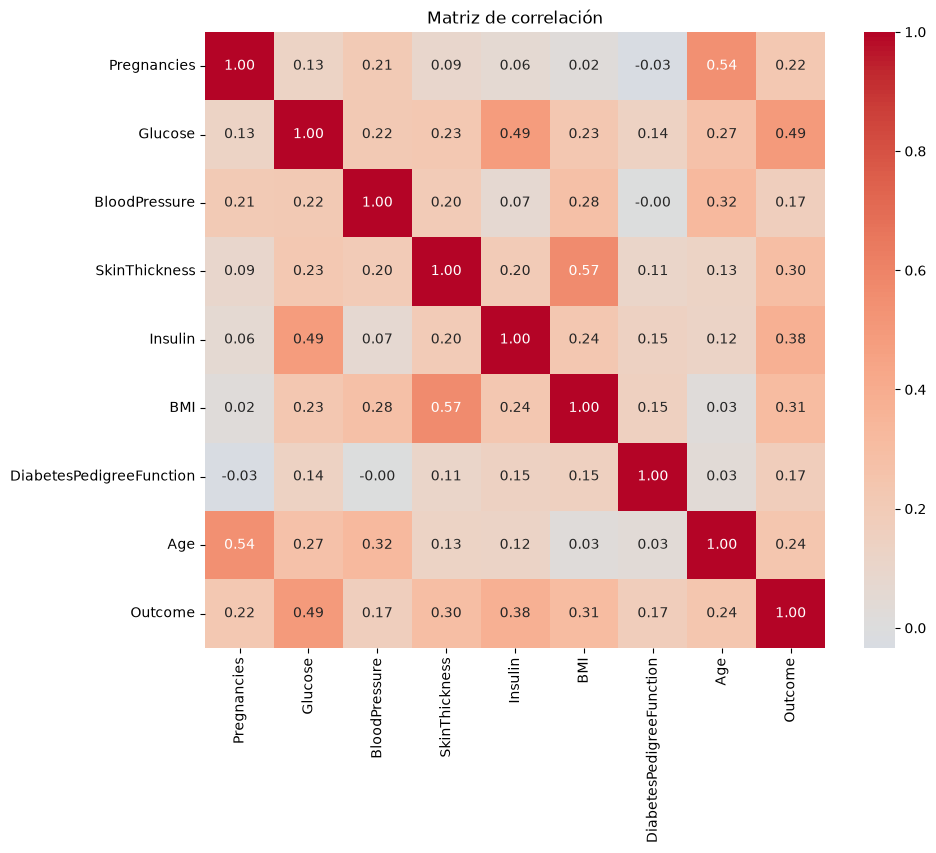

In [13]:
plt.figure(figsize=(10, 8))
corr = df_clean[cols_numericas + ['Outcome']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación')
plt.show()

Como todas las variables son numéricas (no hay categóricas), procedimos a generar gráficos para observar la distribución de los datos, los cuales nos indican:

- glucosa, bmi y presión arterial tienen una distribución normal, lo cual hace sentido desde el punto biológico.
- embarazos, edad y diabetespedigreefunction, tienen forma de colas largas a la derecha, esto igual hace un sentido normal, pues la muestra es a jóvenes, con pocos embarazos y algunos casos extremos.
- skinthikness e insulin muestran claramente el pico artificial de la imputación (este se ve en las medianas del grupo) y la gran cantidad de valores nulos que tenían.

Ahora describiremos los boxplots:

-Glucose: las medianas están claramente distintas y las cajas casi no se solapan. Va a ser probablemente el predictor más fuerte.
- Age: los diabéticos tienden a ser mayores, con buena separación.
- BMI: diabéticos con mediana más alta, separación moderada.
- Pregnancies: diabéticos con más embarazos en mediana (4 vs 2), separación moderada.
- DiabetesPedigreeFunction: leve tendencia a mayor valor en diabéticos, pero con bastante solapamiento.
- BloodPressure y SkinThickness: diferencias muy sutiles entre grupos, probablemente aportarán poco poder predictivo por sí solas.
- Insulin: la mediana se ve casi idéntica entre grupos (por el efecto de la imputación del pico artificial "aplana" la diferencia).

Multicolinealidad entre predictoras (lo que nos importa para no violar supuestos de independencia en la regresión logística):

- SkinThickness y BMI: 0.57, la correlación más alta entre predictoras. Tiene sentido (ambas relacionadas con adiposidad), pero no es tan alta como para preocuparnos por colinealidad severa (umbral de alarma es >0.8-0.9).
- Pregnancies y Age: 0.54, también esperable (a más edad, más probabilidad de haber tenido embarazos).
- Glucose e Insulin: 0.49, razonable fisiológicamente.

**Split/Train test**

In [14]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=['Outcome'])
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nProporción Outcome en train:")
print(y_train.value_counts(normalize=True))
print("\nProporción Outcome en test:")
print(y_test.value_counts(normalize=True))

Train shape: (614, 10)
Test shape: (154, 10)

Proporción Outcome en train:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Proporción Outcome en test:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir de vuelta a DataFrame para mantener nombres de columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Insulin_was_missing,SkinThickness_was_missing
353,-0.851355,-1.056427,-0.826740,-1.895290,-1.170378,-0.769477,0.310794,-0.792169,-0.946077,-0.631374
711,0.356576,0.144399,0.477772,-0.224736,-1.427642,-0.417498,-0.116439,0.561034,-0.946077,-0.631374
373,-0.549372,-0.556083,-1.152868,1.223078,-0.545594,0.359790,-0.764862,-0.707594,-0.946077,-0.631374
46,-0.851355,0.811525,-1.315932,-0.224736,-0.441463,-0.402832,0.262314,-0.369293,1.056996,1.583847
682,-1.153338,-0.889646,-0.663676,1.111708,-0.410836,1.782373,-0.337630,-0.961320,-0.946077,-0.631374


**Modelo base de regresión logística**

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

print("Modelo entrenado.")
print("Coeficientes:")
for feature, coef in zip(X_train_scaled.columns, model.coef_[0]):
    print(f"  {feature}: {coef:.4f}")
print(f"Intercepto: {model.intercept_[0]:.4f}")

Modelo entrenado.
Coeficientes:
  Pregnancies: 0.3264
  Glucose: 0.9501
  BloodPressure: -0.0568
  SkinThickness: 0.3134
  Insulin: 0.6756
  BMI: 0.4743
  DiabetesPedigreeFunction: 0.2065
  Age: 0.1290
  Insulin_was_missing: 0.2884
  SkinThickness_was_missing: -0.0421
Intercepto: -0.9072


In [17]:
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

In [18]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                               f1_score, roc_auc_score, confusion_matrix,
                               classification_report, roc_curve)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification report:")
print(classification_report(y_test, y_pred))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7337662337662337
Precision: 0.6274509803921569
Recall: 0.5925925925925926
F1-score: 0.6095238095238096
ROC-AUC: 0.8322222222222223

Classification report:
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       100
           1       0.63      0.59      0.61        54

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154


Matriz de confusión:
[[81 19]
 [22 32]]


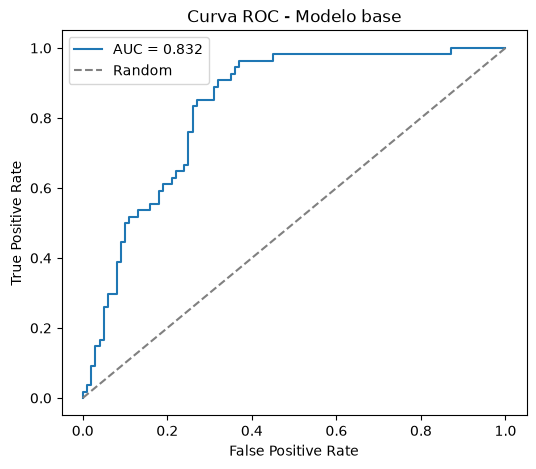

In [19]:
plt.figure(figsize=(6, 5))
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_pred_proba):.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Modelo base')
plt.legend()
plt.show()

- Accuracy 73%, pero eso es engañoso por el desbalance de clases.
- Recall de la clase 1 (diabetes) = 0.59, esto es lo que más me preocupa. De 54 pacientes con diabetes en test, el modelo solo detecta 32 y deja pasar 22 sin diagnosticar (falsos negativos).
- Precision de clase 1 = 0.63 (de los que predice como diabéticos, acierta el 63%).

**Exploración de la curva Precision-Recall vs Threshold**

In [20]:
# Calcular precision, recall y F1 para distintos thresholds
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Evitar división por cero en el cálculo de F1
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

# Armar tabla (nota: thresholds tiene un elemento menos que precisions/recalls)
df_thresholds = pd.DataFrame({
    'threshold': thresholds,
    'precision': precisions[:-1],
    'recall': recalls[:-1],
    'f1': f1_scores[:-1]
})

# Ver algunos puntos de referencia, cada 0.05 aprox en threshold
df_thresholds_sample = df_thresholds[df_thresholds['threshold'].round(2).isin(
    [round(x, 2) for x in np.arange(0.1, 1.0, 0.05)]
)].drop_duplicates(subset='threshold')

df_thresholds_sample

,threshold,precision,recall,f1
45,0.096918,0.486239,0.981481,0.650307
46,0.098424,0.490741,0.981481,0.654321
47,0.099429,0.495327,0.981481,0.658385
48,0.104971,0.500000,0.981481,0.662500
58,0.149765,0.541667,0.962963,0.693333
62,0.202141,0.565217,0.962963,0.712329
68,0.247902,0.581395,0.925926,0.714286
69,0.248597,0.588235,0.925926,0.719424
74,0.298672,0.600000,0.888889,0.716418
75,0.300016,0.607595,0.888889,0.721805


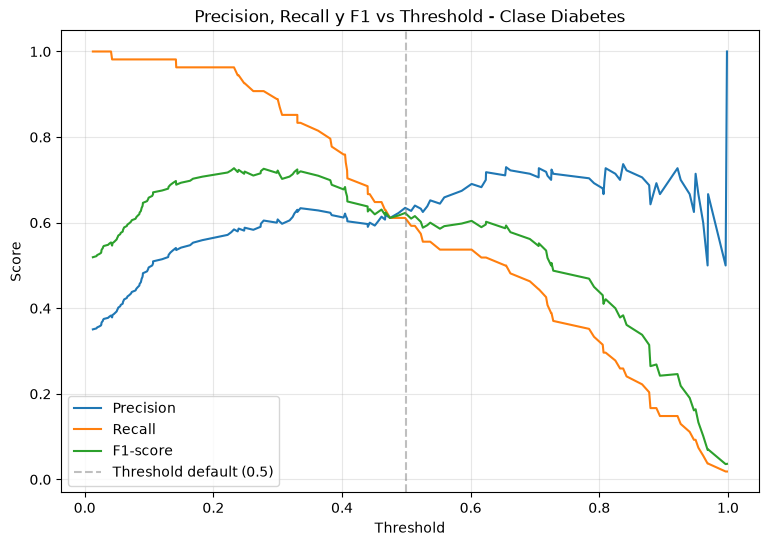

In [21]:
# Precision, recall y F1 vs threshold
plt.figure(figsize=(9, 6))
plt.plot(df_thresholds['threshold'], df_thresholds['precision'], label='Precision')
plt.plot(df_thresholds['threshold'], df_thresholds['recall'], label='Recall')
plt.plot(df_thresholds['threshold'], df_thresholds['f1'], label='F1-score')
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Threshold default (0.5)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall y F1 vs Threshold - Clase Diabetes')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

- El F1 máximo está alrededor de threshold = 0.30, con recall de 0.87-0.89 y precision≈0.60-0.61.
- Para asegurar un recall ≥ 0.80, el threshold tiene que estar entre 0.30 y 0.40 aproximadamente (a threshold=0.30 el recall es 0.87; a threshold=0.40 ya cae a 0.76).
- Subir el threshold por encima de 0.40 mejora precision pero el recall se derrumba rápido.

In [22]:
# Encontrar el threshold óptimo con piso de recall = 0.80
recall_floor = 0.80

# Filtrar combinaciones que cumplen el piso de recall
mask = recalls[:-1] >= recall_floor
precisions_validas = precisions[:-1][mask]
recalls_validos = recalls[:-1][mask]
thresholds_validos = thresholds[mask]

# De las que cumplen el piso, elegir la de mayor precision
idx_optimo = np.argmax(precisions_validas)
threshold_optimo = thresholds_validos[idx_optimo]

print(f"Threshold óptimo (recall >= {recall_floor}): {threshold_optimo:.4f}")
print(f"Precision en ese punto: {precisions_validas[idx_optimo]:.4f}")
print(f"Recall en ese punto: {recalls_validos[idx_optimo]:.4f}")

Threshold óptimo (recall >= 0.8): 0.3355
Precision en ese punto: 0.6338
Recall en ese punto: 0.8333


In [23]:
# Aplicar el threshold óptimo y evaluar
y_pred_optimo = (y_pred_proba >= threshold_optimo).astype(int)

print("Métricas con threshold ajustado:")
print("Accuracy:", accuracy_score(y_test, y_pred_optimo))
print("Precision:", precision_score(y_test, y_pred_optimo))
print("Recall:", recall_score(y_test, y_pred_optimo))
print("F1-score:", f1_score(y_test, y_pred_optimo))
print("\nClassification report:")
print(classification_report(y_test, y_pred_optimo))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_optimo))

Métricas con threshold ajustado:
Accuracy: 0.7727272727272727
Precision: 0.6338028169014085
Recall: 0.8333333333333334
F1-score: 0.72

Classification report:
              precision    recall  f1-score   support

           0       0.89      0.74      0.81       100
           1       0.63      0.83      0.72        54

    accuracy                           0.77       154
   macro avg       0.76      0.79      0.76       154
weighted avg       0.80      0.77      0.78       154


Matriz de confusión:
[[74 26]
 [ 9 45]]


Bajamos de 22 a 9 pacientes diabéticos no detectados (de 54 casos reales, ahora detectamos 45), a cambio de 7 falsos positivos adicionales (26 vs 19 pacientes sanos que el modelo marca para estudio adicional). Es un trade-off muy razonable para este contexto y lo bueno es que la precision casi no se movió (0.627 → 0.634).